
---

# 🤖 **`Overfitting vs. Underfitting in Machine Learning for Data Science`** 📊  

In **Machine Learning (ML)**, achieving the right balance between **model complexity** and **generalization** is crucial. Two common problems that arise during model training are:  

1. **Overfitting** — when the model learns **too much** from the training data (including noise).  
2. **Underfitting** — when the model learns **too little** and fails to capture the underlying pattern.  

Both lead to **poor performance** on **unseen data**. Understanding these concepts is essential for building models that **generalize well** to new data.  

---

## 🧠 **1. What is Overfitting?** 🔥  

### ✅ **Definition:**  
**Overfitting** occurs when a model learns the **training data too well**, including its **noise** and **outliers**, leading to poor generalization on **new, unseen data**.  

📌 **Key Characteristics of Overfitting:**  
- **High accuracy** on training data  
- **Poor performance** on test/validation data  
- The model is **too complex** (e.g., too many features or layers)  

### 📊 **Example Scenario:**  
Imagine training a model to predict house prices. If the model memorizes every fluctuation in the training data (including random anomalies), it may perform well on training data but poorly on new data.  

---

### 📈 **Visualizing Overfitting:**  
- **Training Error:** Very low  
- **Validation/Test Error:** Very high  

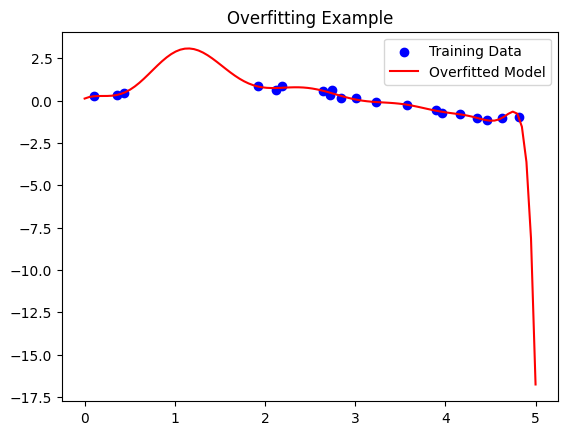

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Simulated Data
np.random.seed(0)
X = np.sort(5 * np.random.rand(20, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(20) * 0.1  # Adding noise

# Overfitted Model (High-Degree Polynomial)
poly = PolynomialFeatures(degree=15)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# Predictions
X_test = np.linspace(0, 5, 100).reshape(-1, 1)
X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

# Plot
plt.scatter(X, y, color='blue', label='Training Data')
plt.plot(X_test, y_pred, color='red', label='Overfitted Model')
plt.title('Overfitting Example')
plt.legend()
plt.show()




---

### ⚠️ **Causes of Overfitting:**  
1. **Too many features** relative to the number of samples.  
2. **Complex models** (deep neural networks, high-degree polynomials).  
3. **Noisy data** that introduces random fluctuations.  
4. **Insufficient training data**.  

---

### 💡 **How to Prevent Overfitting?**  
| **Technique**             | **Description**                             |
|---------------------------|---------------------------------------------|
| **Cross-Validation** 🔄    | Split data into train/test sets multiple times.  
| **Regularization** 📏      | Apply penalties (L1/L2) to reduce complexity.  
| **Pruning (for Trees)** 🌳 | Remove nodes that add minimal value.  
| **Dropout (for Neural Nets)** 🤖 | Randomly drop neurons during training.  
| **Early Stopping** ⏰      | Stop training when validation error increases.  
| **More Data** 📊           | Training on larger datasets improves generalization.  




---

## 🧠 **2. What is Underfitting?** ❄️  

### ✅ **Definition:**  
**Underfitting** occurs when a model is **too simple** to capture the underlying structure of the data, leading to **poor performance** on both the **training** and **test** datasets.  

📌 **Key Characteristics of Underfitting:**  
- **High bias** and **low variance**  
- **Poor accuracy** on both training and test data  
- Model is **too simple** (e.g., linear model for non-linear data)  

### 📊 **Example Scenario:**  
If you try to fit a simple **linear regression** model to data that follows a complex, non-linear trend, the model will fail to capture the underlying relationship.  

---

### 📈 **Visualizing Underfitting:**  
- **Training Error:** High  
- **Validation/Test Error:** High  


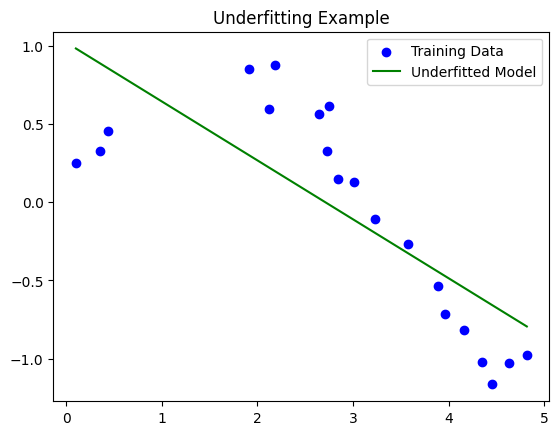

In [2]:

# Underfitted Model (Linear Regression)
model_underfit = LinearRegression()
model_underfit.fit(X, y)
y_pred_underfit = model_underfit.predict(X)

# Plot
plt.scatter(X, y, color='blue', label='Training Data')
plt.plot(X, y_pred_underfit, color='green', label='Underfitted Model')
plt.title('Underfitting Example')
plt.legend()
plt.show()



---

### ⚠️ **Causes of Underfitting:**  
1. **Overly simple models** (e.g., Linear Regression for complex data).  
2. **Insufficient features** used for prediction.  
3. **Inadequate training time** or **poor hyperparameter tuning**.  
4. **Over-regularization** (too much penalty on complexity).  

---

### 💡 **How to Prevent Underfitting?**  
| **Technique**             | **Description**                           |
|---------------------------|-------------------------------------------|
| **Use More Complex Models** 🤖 | Try Decision Trees, Random Forests, or Neural Networks.  
| **Feature Engineering** 🛠️ | Create new features that better capture patterns.  
| **Reduce Regularization** 📏 | Decrease L1/L2 penalties if they limit learning.  
| **Increase Training Time** ⏰ | Train the model longer or with better hyperparameters.  
| **Hyperparameter Tuning** 🎛️ | Adjust model parameters to improve fit.  




---

## ⚔️ **3. Overfitting vs. Underfitting: Side-by-Side Comparison**  

| **Aspect**              | **Overfitting** 🔥               | **Underfitting** ❄️            |
|-------------------------|---------------------------------|-------------------------------|
| **Training Error**       | Very Low                        | High                          |
| **Validation/Test Error** | High                           | High                          |
| **Bias**                 | Low                             | High                          |
| **Variance**             | High                            | Low                           |
| **Model Complexity**     | Too Complex                     | Too Simple                    |
| **Example Model**        | High-degree polynomial          | Linear Regression (on non-linear data) |
| **Solution**             | Simplify model, regularization   | Use more complex models, feature engineering |



---

## 📊 **4. The Bias-Variance Trade-Off** ⚖️  

The **Bias-Variance Trade-Off** helps explain **Overfitting** and **Underfitting**:  

- **Bias:** Error due to overly simplistic assumptions → leads to **underfitting**.  
- **Variance:** Error due to model complexity and sensitivity to data fluctuations → leads to **overfitting**.  

#### ✅ **Goal:** Find the sweet spot where both bias and variance are minimized, achieving **optimal generalization**.  

```plaintext
Error
│
│         🔺
│        / \
│       /   \        <- Total Error
│      /     \
│────/───────\─────
   High Bias   High Variance
    (Underfit)   (Overfit)
```



---

## 🤔 **5. How to Detect Overfitting & Underfitting?**  

### 📌 **1. Learning Curves (Training vs. Validation Loss):**  
- **Overfitting:**  
  - Training loss → ↓  
  - Validation loss → ↑ (after certain epochs)  
- **Underfitting:**  
  - Both training & validation loss → High  

### 📌 **2. Cross-Validation:**  
- Evaluate model on **multiple data splits** to check for consistent performance.  

### 📌 **3. Performance Metrics:**  
- **Classification Tasks:** Accuracy, F1-Score, ROC-AUC  
- **Regression Tasks:** MSE (Mean Squared Error), R² Score  



---

## 🎯 **6. Quick Tips to Handle Overfitting & Underfitting:**  

| **Problem**            | **Solution**                          |
|------------------------|---------------------------------------|
| **Overfitting** 🔥     | Cross-Validation, Regularization, Pruning  
| **Underfitting** ❄️   | Add Features, Use Complex Models, Reduce Regularization  
| **Both** ⚖️          | Tune Hyperparameters, Adjust Model Complexity  




---

## 🏆 **7. Final Thoughts:**  

✔ **Overfitting** → The model knows the training data **too well** but fails to generalize.  
✔ **Underfitting** → The model is **too simple** to capture meaningful patterns.  
✔ The key to successful ML is finding the **right balance** between **bias** and **variance**.  
✔ Always validate models on **unseen data** to detect overfitting or underfitting.  


💡 **Pro Tip:** Start simple and gradually increase complexity while monitoring validation performance.  

---